In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
import random 
random.seed(3)
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [2]:
#RMSE/MAE analysis
def time_reader(fname, core=4):
    lines=open(fname).readlines()
    start_iter=0
    end_iter = 0
    counter=0
    str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    start_iter = datetime.strptime(str_dt, "%H:%M:%S")
    core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
    str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    end_iter = datetime.strptime(str_dt, "%H:%M:%S")
    return (core_times, start_iter, end_iter)

def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 



In [42]:
# bramble-1-1 39
# bramble-1-3 38
# bramble-1-4 39
# bramble-2-1 23
# bramble-2-2 41
# bramble-2-4 39
# bramble-2-5 38
# bramble-2-6 35
# bramble-4-1 36
# bramble-4-2 0
# bramble-4-3 26
# bramble-4-5 38
# bramble-4-6 32

total_flops_map = {"resnet18": 3628146688, "tcn": 21525774336, "vit":33697001472}

def tf_calc(w, n):
    y=0
    if w < 8:
        y = 0.157 - 0.004*n + 0.075*w
    else:
        y = 0.667 - 0.008*n + 0.023*w
    return y

def constrained_sum_sample_pos(n, total):
    """Return a randomly chosen list of n positive integers summing to total.
    Each such list is equally likely to occur."""

    dividers = sorted(random.sample(range(10, total), n - 1))
    return [a - b for a, b in zip(dividers + [total], [0] + dividers)]

def constrained_sum_sample_nonneg(n, total):
    """Return a randomly chosen list of n nonnegative integers summing to total.
    Each such list is equally likely to occur."""
    return [x - 1 for x in constrained_sum_sample_pos(n, total + n)]


def time_predictor(peak_times, fp, bg_load=0):
    maybe_gnt = [0]*len(peak_times)
    achieved_fps = [i for i in peak_times]
    if len(peak_times)==1 and bg_load==0:
        return achieved_fps
    elif len(peak_times)==1:
        val = tf_calc(len(peak_times)+bg_load, 38)
        # print(val, bg_load)
        val = val if val < 1 else 0.99
        gnt = (peak_times[0]-maybe_gnt[0])/(1-val)
        achieved_fps = [gnt]
        return achieved_fps

    for ind, i in enumerate(peak_times):
        # if (i-maybe_bnt[ind]) > 0 and len(peak_times)-ind>0:
        #     bnt = (i-maybe_bnt[ind])*tf_calc(len(peak_times)-ind, 38) + (i-maybe_bnt[ind]) #if tf = (t-p)/p
        #     for k in range(ind, len(maybe_bnt)):
        #         maybe_bnt[k] = maybe_bnt[k]+bnt
        # else:
        #     bnt = (i-maybe_bnt[ind])*tf_calc(len(peak_times)-ind, 38) + (i-maybe_bnt[ind])
            # print(bnt)
        if (i-maybe_gnt[ind]) > 0 and len(peak_times)-ind>0:
            val = tf_calc(len(peak_times)-ind+bg_load, 38)
            # print(val, bg_load)
            val = val if val < 1 else 0.99
            gnt = (i-maybe_gnt[ind])/(1-val) #if tf = (t-p)/t
            for k in range(ind, len(maybe_gnt)):
                maybe_gnt[k]=maybe_gnt[k]+gnt
                achieved_fps[k] = fp[k]*maybe_gnt[ind]/fp[ind] + (fp[k]-fp[ind])*peak_times[ind]/fp[ind]
        # else:
        #     gnt = (i-maybe_gnt[ind])/(1-tf_calc(len(peak_times)-ind, 38))
    return achieved_fps

def bn_calc(fp, bn, fixed_iters=1, peak_rate=4.8, bg_load=0):
    og_fp =[f for f in fp]
    fp = [f for f in sorted(fp)]
    # og_fp = sorted(fp, reverse=True)
    # og_fp = sorted(fp)
    

    # og_fp = fp[:len(fp)//2] + [max(fp)]
    # c=0
    # for f in sorted(fp[len(fp)//2:],reverse=True):
    #     if c==0 and f==max(fp):
    #         c+=1
    #         continue
    #     og_fp.append(f)
    # print(fp, og_fp)
    
    # og_fp = og_fp + [f for f in fp if fp not in og_fp]
    throttled_latency = 0
    peak_latency = 0
    min_util = np.inf
    back_col=0
    rank_to_time_step_map={r:[0]*r+[og_fp[r]]*bn+[0]*(len(og_fp)-r-1) for r in range(len(og_fp))}
    for time_step in range(len(rank_to_time_step_map[0])): #always has rank 0 -> single ml model, no splits
        slice_fp = [rank_to_time_step_map[r][time_step] for r in rank_to_time_step_map]
        slice_fp = [s for s in slice_fp if s!=0]

    # for col in range(bn+len(fp)-1):
    #     slice_fp=[]
    #     if col < bn:
    #         slice_fp = og_fp[:col+1]
    #     if col >= bn:
    #         slice_fp = og_fp[back_col+1:]
    #         back_col+=1
        slice_fp = sorted(slice_fp)
        slice_pt = [f*fixed_iters*10**-3/peak_rate for f in slice_fp]
        # tf=0
        # if max(slice_fp) == min(slice_fp) and len(slice_fp)>1:
        #     #even split case
        #     tf = tf_calc(len(slice_fp), 38) #hardcoding 38 for now
        #     time_list = [s_pt/(1-tf) for s_pt in slice_pt]
        # else:
        time_list = time_predictor(slice_pt, slice_fp, bg_load)
        # if bn==5:
        # print(time_list, col, fp, bn, slice_fp, bg_load)
        # print(time_list)
        throttled_latency += max(time_list)
        peak_latency += max(slice_pt)
        min_util = min(min(time_list)/max(time_list), min_util)
    return throttled_latency, min_util, peak_latency

In [81]:
#RMSE/MAE calcs
subclusters=["bramble-4-1"]
fixed_iters=10
peak_rate=4.8 #gflop/s

for p in subclusters:
    parent_dir = Path(f"/Users/animeshnd/model_splitting/logs/full_pipeline/{p}/")
    # fig, axs = plt.subplots(figsize=(25,10))
    for file_path in parent_dir.iterdir():
        # if file_path.is_dir() and "onnx" in str(file_path) and "onnx_inter" not in str(file_path):
        # if file_path.is_dir() and "onnx_inter" in str(file_path):
        if file_path.is_dir() and "onnx" in str(file_path):
            model_id = str(file_path).split("/")[-1].split("_")[0]
            model_split = str(file_path).split("/")[-1].split("_")[1]
            # print(file_path)
            # if model_id!="vit":
            #     continue
            if model_id!="tcn":
                continue
            # print(model_id)
            # print(model_id)
            # if model_id!="resnet18":
            #     continue
            dev_map={}
            for time_slice_dir in file_path.iterdir():
                time_slice = int(str(time_slice_dir).split("/")[-1])
                if time_slice not in dev_map:
                    dev_map[time_slice]={2:{}, 5:{}}
                for repeat in range(1,11):
                    full_dir_path = Path(f"{time_slice_dir}/{repeat}/")
                    for f in full_dir_path.iterdir():
                        f=str(f)
                        world, rank =f.split("_")[-2:]
                        world = int(world)
                        rank = int(rank.split(".")[0])
                        core_times, s_dt, e_dt = time_reader(f, core=4)
                        if rank not in dev_map[time_slice][world]:
                            dev_map[time_slice][world][rank]=[]
                        
                        dev_map[time_slice][world][rank].append(max(core_times))
                dev_map[time_slice][world] = {k:v for k,v in sorted(dev_map[time_slice][world].items(), key=lambda x: x[0])}
            dev_map = {k:v for k,v in sorted(dev_map.items(), key=lambda x: x[0])}
            # print(dev_map)

            #read flop dict for model
            
            for world in [2,5]:
                real_time = []
                max_real_time = 0
                fake_time=0
                for col in dev_map:
                    flop_dict_file = open(Path(f"../aot_splitter/{model_id}_{model_split}_{world}_1_custom/flop.dict"))
                    flop_dict = ast.literal_eval(flop_dict_file.readlines()[0].strip())
                    stage_dict_file = open(Path(f"../aot_splitter/{model_id}_{model_split}_{world}_1_custom/stages.dict"))
                    pair_wise_real_times=[]
                    # pair_wise_fake_times=[]
                    for r_ind, r in enumerate(dev_map[col][world]):
                        pair_wise_real_times.append([])
                        for v in dev_map[col][world][r]:
                            pair_wise_real_times[r_ind].append(v)
                    # print(pair_wise_real_times)
                    if len(pair_wise_real_times)==0:
                        continue
                    real_time.append(pair_wise_real_times)
                    # print( max([ max(dev_map[col][world][r]) for r in dev_map[col][world]]))
                    max_real_time+=max([ np.max(dev_map[col][world][r]) for r in dev_map[col][world]])
                    fp = sorted([flop_dict[r] for r in dev_map[col][world]])
                    peak_times = [f*fixed_iters*10**-9/peak_rate for f in fp]
                    fake_time+=max(time_predictor(peak_times, fp))
                print(world, fake_time, max_real_time)
                    # fake_time+=

                    # print(fp)
                    # peak_times = []
                    # fake_time += 

# resnet   
# 2 12.89688557427322 14.84
# 5 26.49122530755965 27.9202

#vit
# 2 112.50340203550297 117.4039
# 5 200.2910853087486 180.3113

#tcn
# 2 69.98720552570106 107.1677
# 5 115.95769226792743 133.6975


{0: {2: {0: [28.417, 28.262, 28.297, 32.095, 28.249, 28.242, 28.255, 28.385, 28.276, 28.245]}, 5: {0: [13.17, 12.426, 12.625, 12.398, 12.463, 12.549, 12.602, 12.472, 12.449, 12.394]}}, 1: {2: {0: [28.285, 28.27, 28.274, 32.551, 28.299, 28.333, 28.193, 28.207, 28.286, 28.267], 1: [39.435, 39.789, 40.011, 39.811, 34.684, 39.982, 39.791, 40.136, 39.805, 39.791]}, 5: {0: [12.414, 12.652, 12.472, 12.45, 12.356, 12.613, 12.446, 12.525, 12.487, 12.546], 1: [12.116, 12.176, 11.897, 12.096, 11.937, 12.091, 11.84, 12.102, 11.949, 12.098]}}, 2: {2: {1: [39.836, 39.356, 40.054, 39.836, 34.684, 39.538, 39.791, 39.331, 39.571, 39.722]}, 5: {0: [12.388, 12.445, 12.52, 12.388, 12.376, 12.492, 12.5, 12.384, 12.497, 12.551], 1: [12.037, 12.288, 11.944, 11.931, 12.028, 12.051, 12.1, 11.966, 12.102, 12.009], 2: [12.101, 13.858, 13.961, 12.074, 13.901, 12.214, 13.893, 12.144, 12.066, 12.065]}}, 3: {2: {}, 5: {0: [12.465, 12.584, 12.422, 12.391, 12.437, 12.535, 12.442, 12.591, 12.552, 12.52], 1: [12.14, 11.

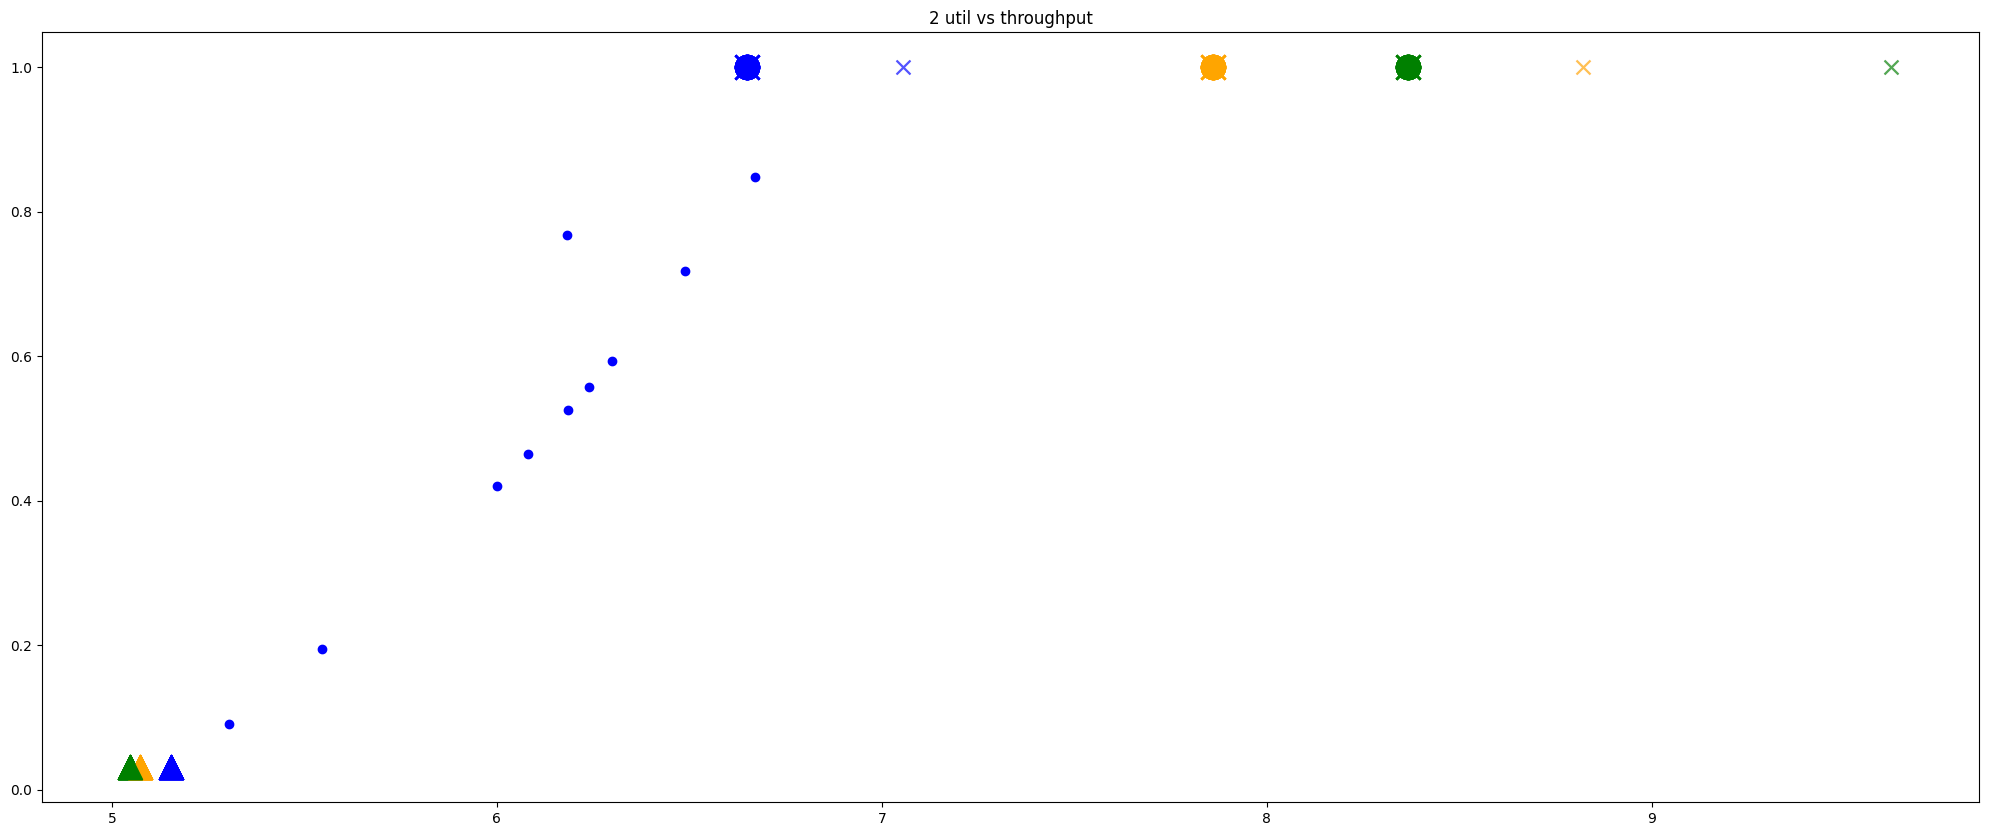

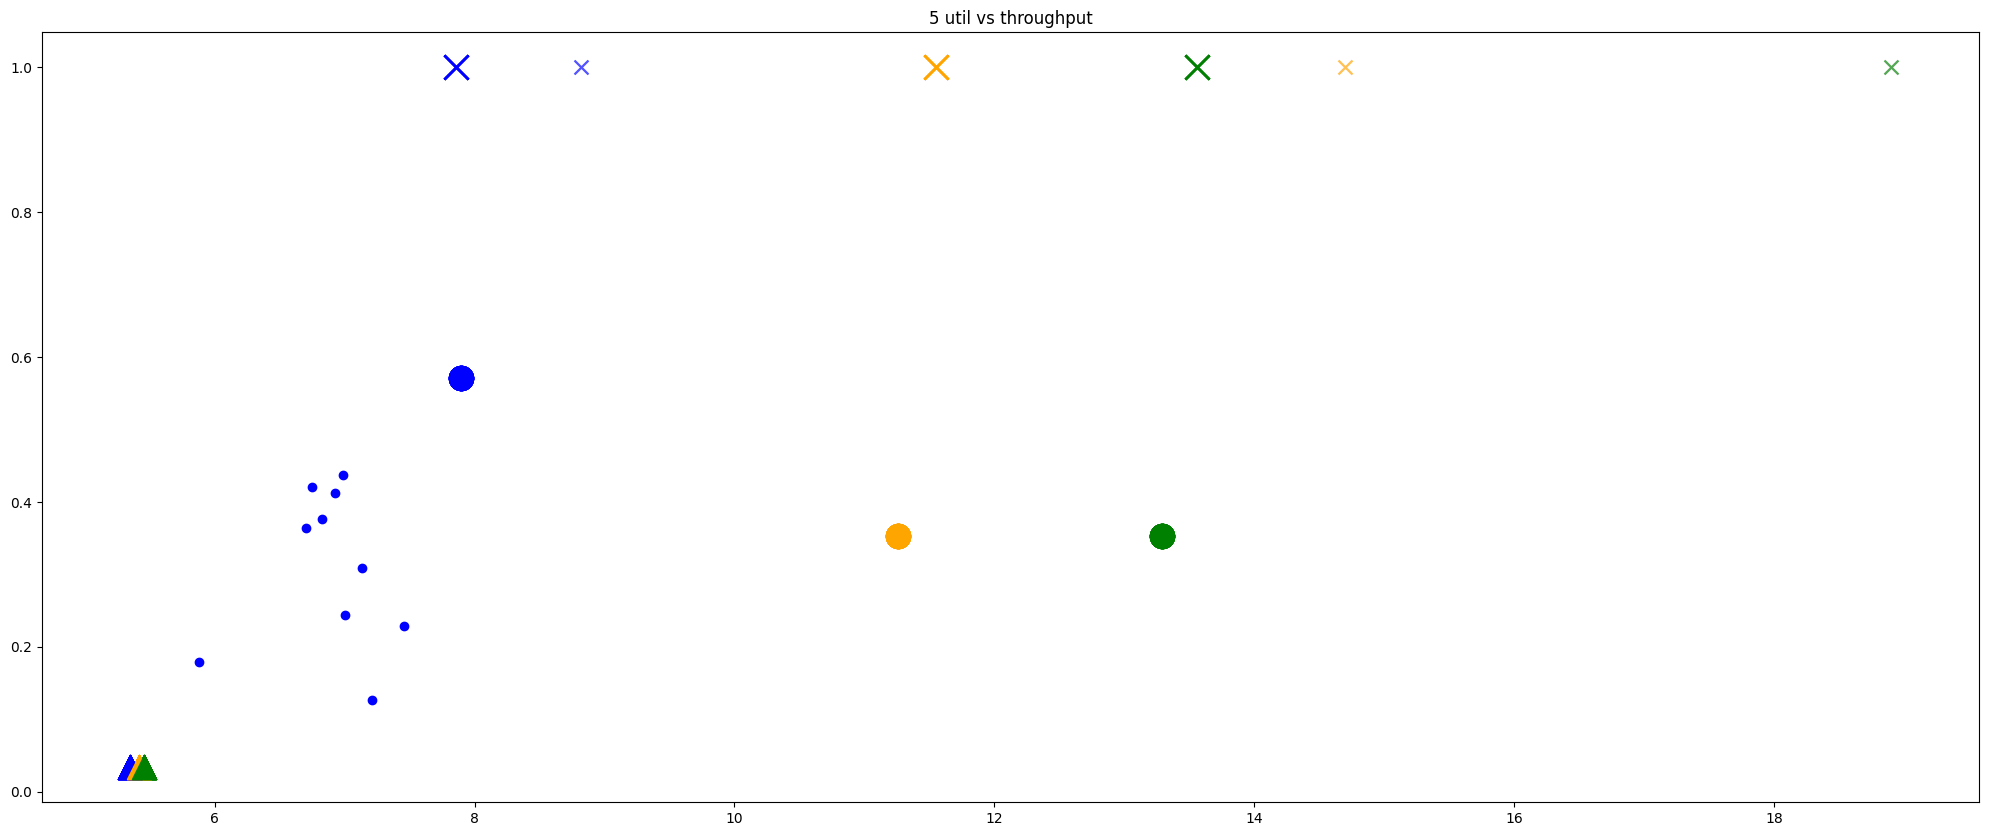

In [44]:
#for resnet make util vs throttle fraction graph ? 
#is this throttle fraction end to end ? or do we want to make this slow down?
splits = [2,5]
fixed_iters = 1 #batch_size = 4*1
peak_rate = 4.8 #gflop/s
#network throttling? -> check with a subcluster how much overhead does this actually have?
random.seed(3)
bn_color_map = {2:"blue", 5:"orange", 10:"green"}
batch_nums = list(bn_color_map.keys())
model="resnet18"
# model="vit"
# model="tcn"
for world in splits:
    fig, axs = plt.subplots(figsize=(25,10))
    visited_trials=[]
    x=[] #slow down
    y=[] #util
    for trial in range(10):
    # for bn in batch_nums:
        fp = sorted(constrained_sum_sample_pos(world, round(total_flops_map[model]*10**-6)))
        peak_times = [f*fixed_iters*10**-3/peak_rate for f in fp]
        if fp not in visited_trials:
            visited_trials.append(fp)

        # for trial in range(1):
        for bn in batch_nums:
            img_procs = bn*fixed_iters*4
            #ten points on the pareto curve
            # back_fp = fp * bn
            # back_pt = peak_times * bn
            
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)

            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn])

            #special cases:
            #all equal split
            fp = [round(total_flops_map[model]*10**-6)/world]*world
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)
            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn], marker="x", s=300)
            axs.scatter(img_procs/peak_latency, min_util, color=bn_color_map[bn], alpha=0.1, marker="x", s=100)

            #fully unbalanced
            fp = [100]*(world-1) + [round(total_flops_map[model]*10**-6) - 100*(world-1)]
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)
            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn], marker="^", s=300)

            #ideal unbalanced
            h=round(total_flops_map[model]*10**-6)/world
            l= (world-1)*round(total_flops_map[model]*10**-6)/world
            fp = [ (l/(sum( range(1, world))))*i for i in range(1,world) ] + [h]
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)

            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn], marker="o", s=300)
        # raise Exception("end it here")
            # x.append(img_procs/throttled_latency)
            # y.append(min_util)
        # axs.scatter(x,y)
    axs.set_title(f"{world} util vs throughput")

    
        

                





            

            









2 even: 0.017931377777777778 [0.5050716551154056, 0.4949283448845945]
2 uneven: 0.017931377777777778 [0.5050716551154056, 0.4949283448845945]
2 spec: 0.017931377777777778 [0.5050716551154056, 0.4949283448845945]
3 even: 0.035862755555555556 [0.3401293998506566, 0.3299515493261427, 0.32991905082320067]
3 uneven: 0.035862755555555556 [0.17518714458590764, 0.3299515493261427, 0.4948613060879497]
3 spec: 0.035862755555555556 [0.25765827221828214, 0.3299515493261427, 0.4123901784555752]
4 even: 0.053794133333333334 [0.2576582722182821, 0.2474804216937682, 0.24741338289712342, 0.24744792319082617]
4 uneven: 0.053794133333333334 [0.09271601695353317, 0.16500929406139372, 0.24741338289712347, 0.4948613060879497]
4 spec: 0.053794133333333334 [0.09278305575017792, 0.24741338289712347, 0.24741338289712347, 0.4123901784555752]


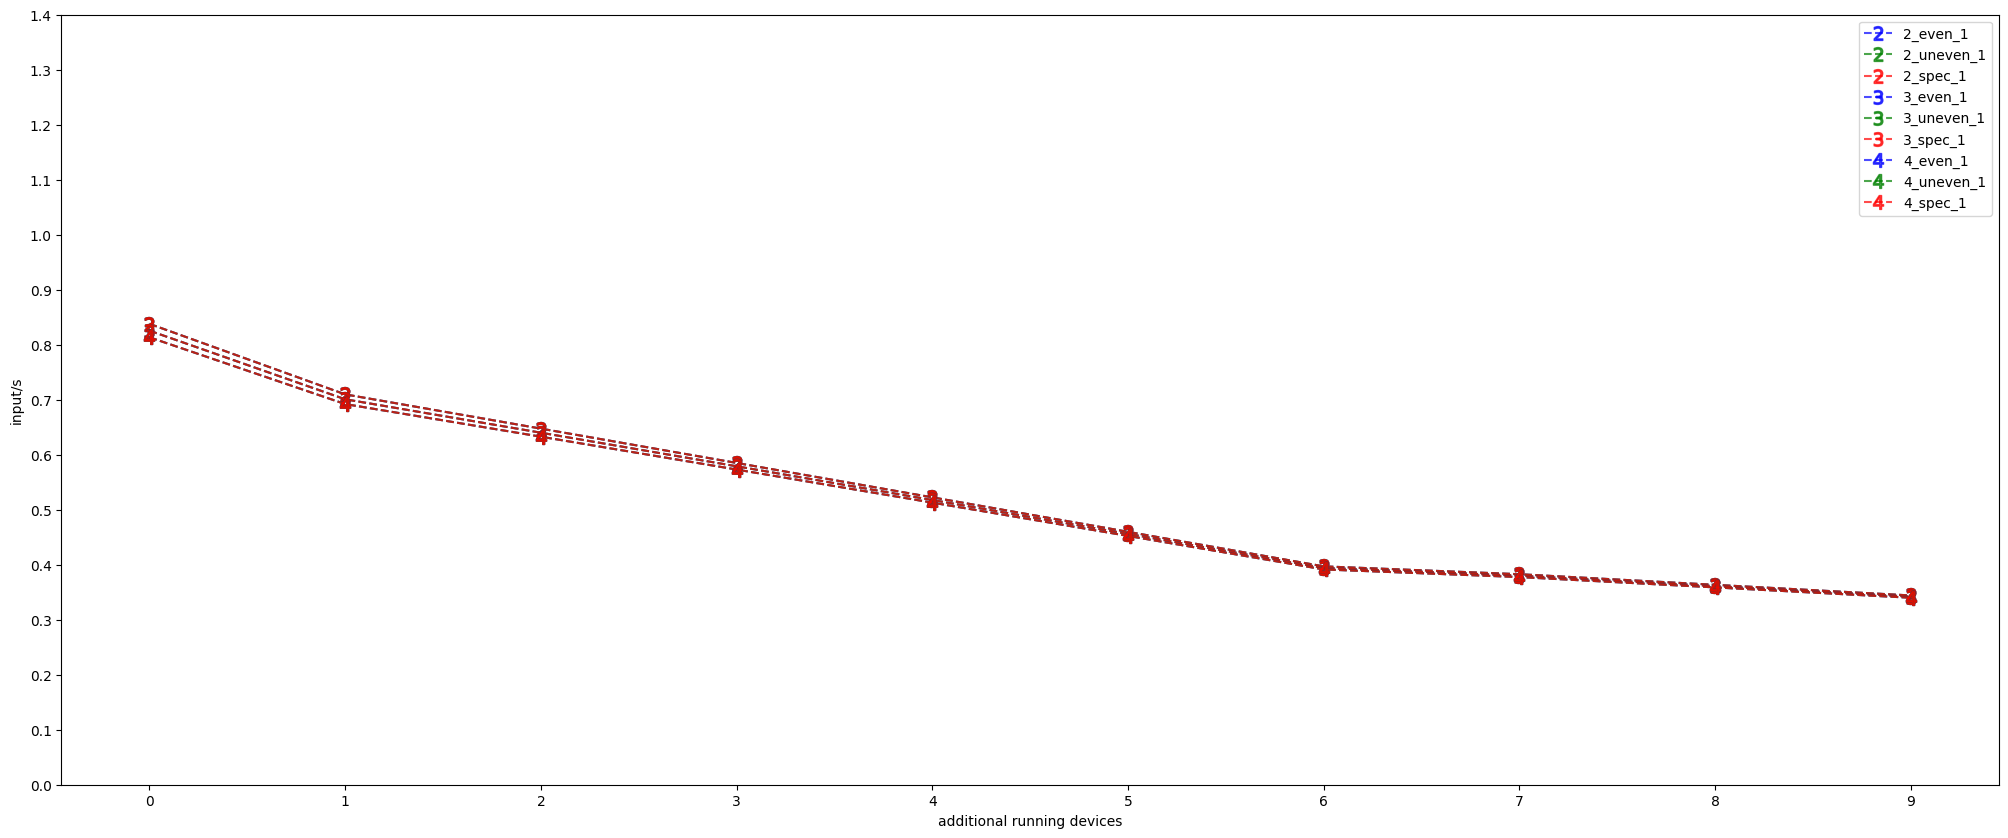

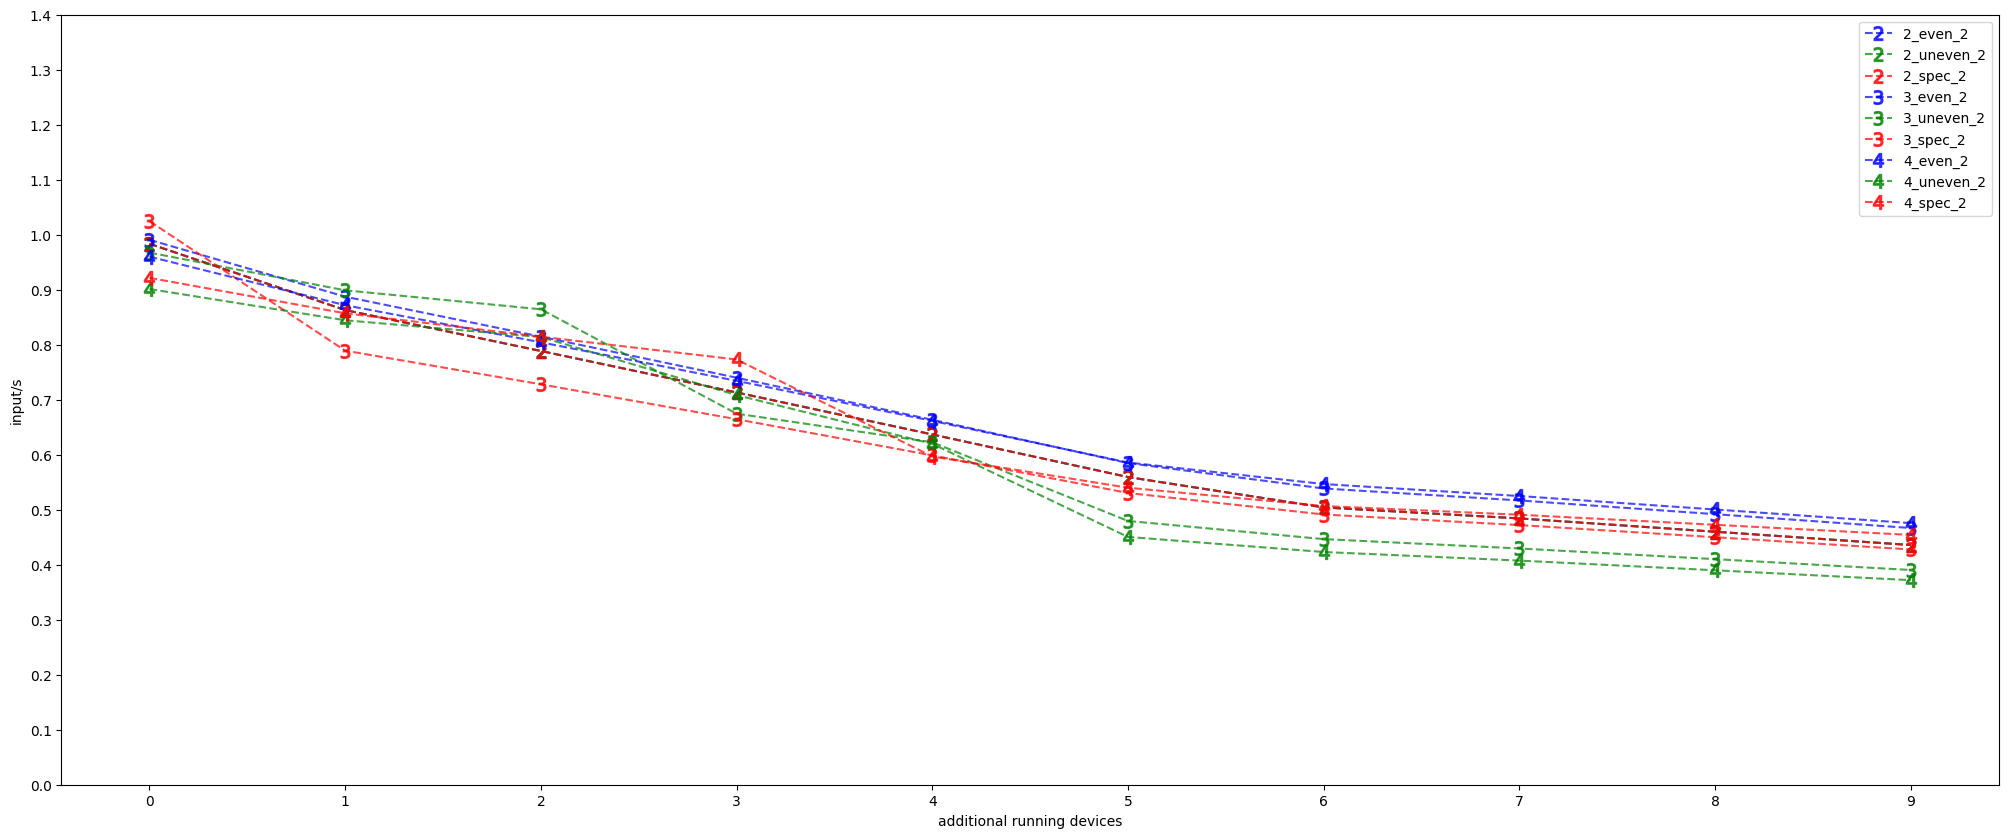

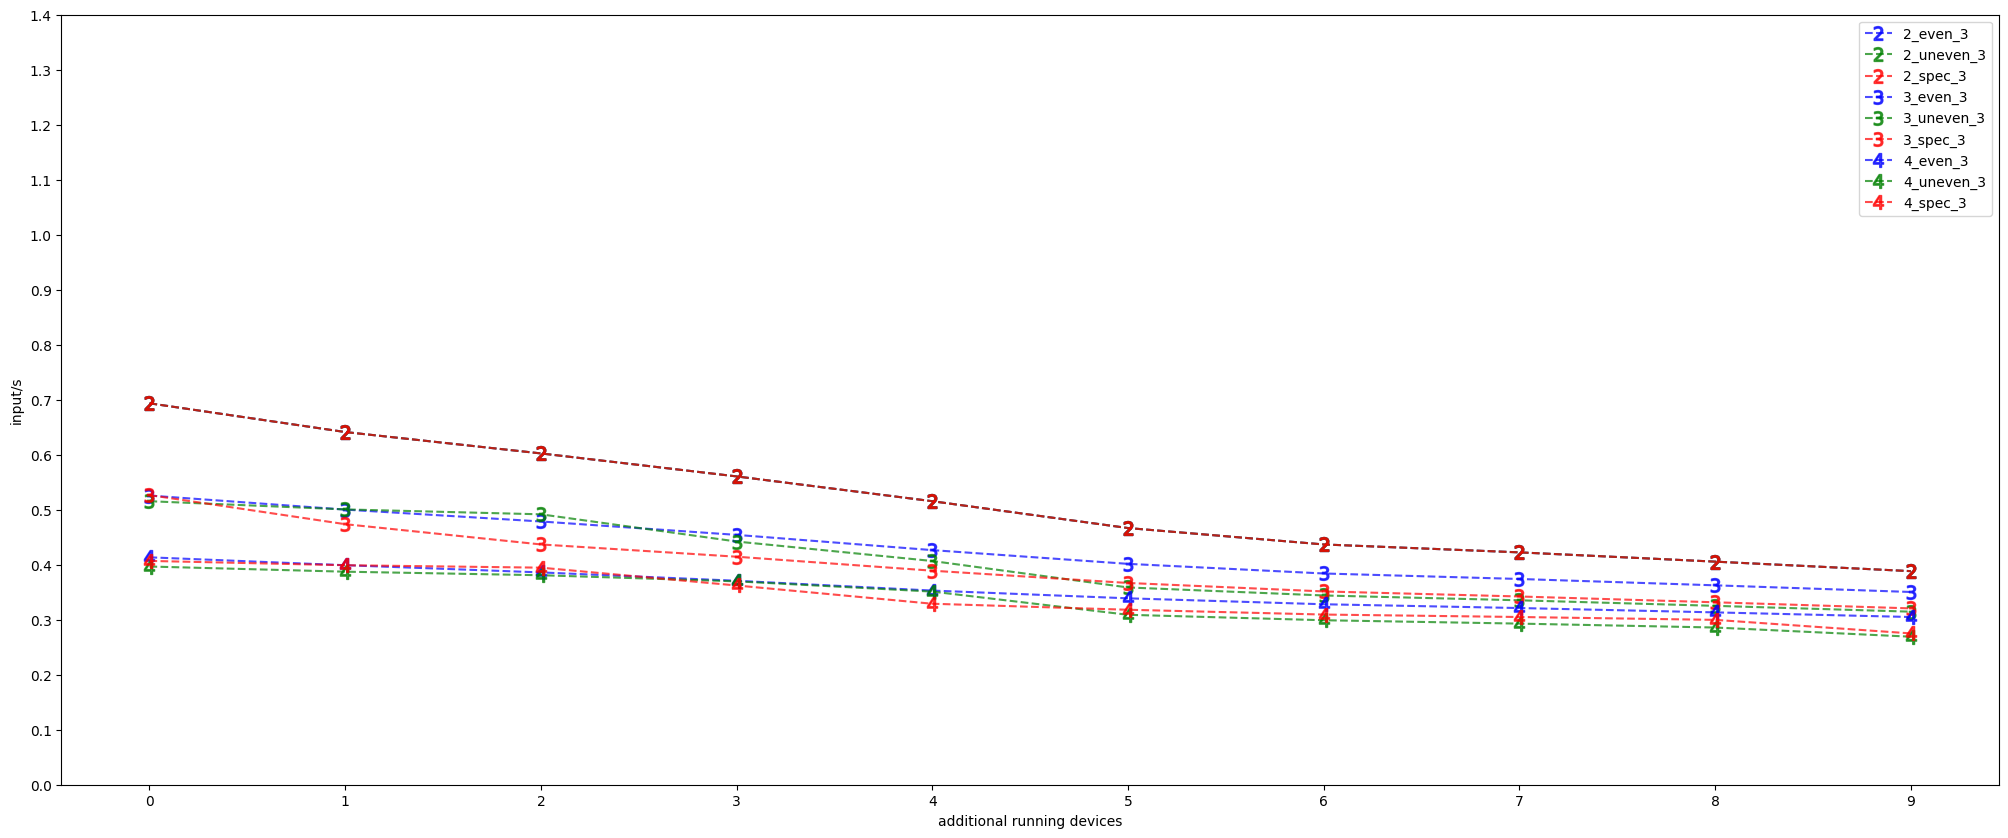

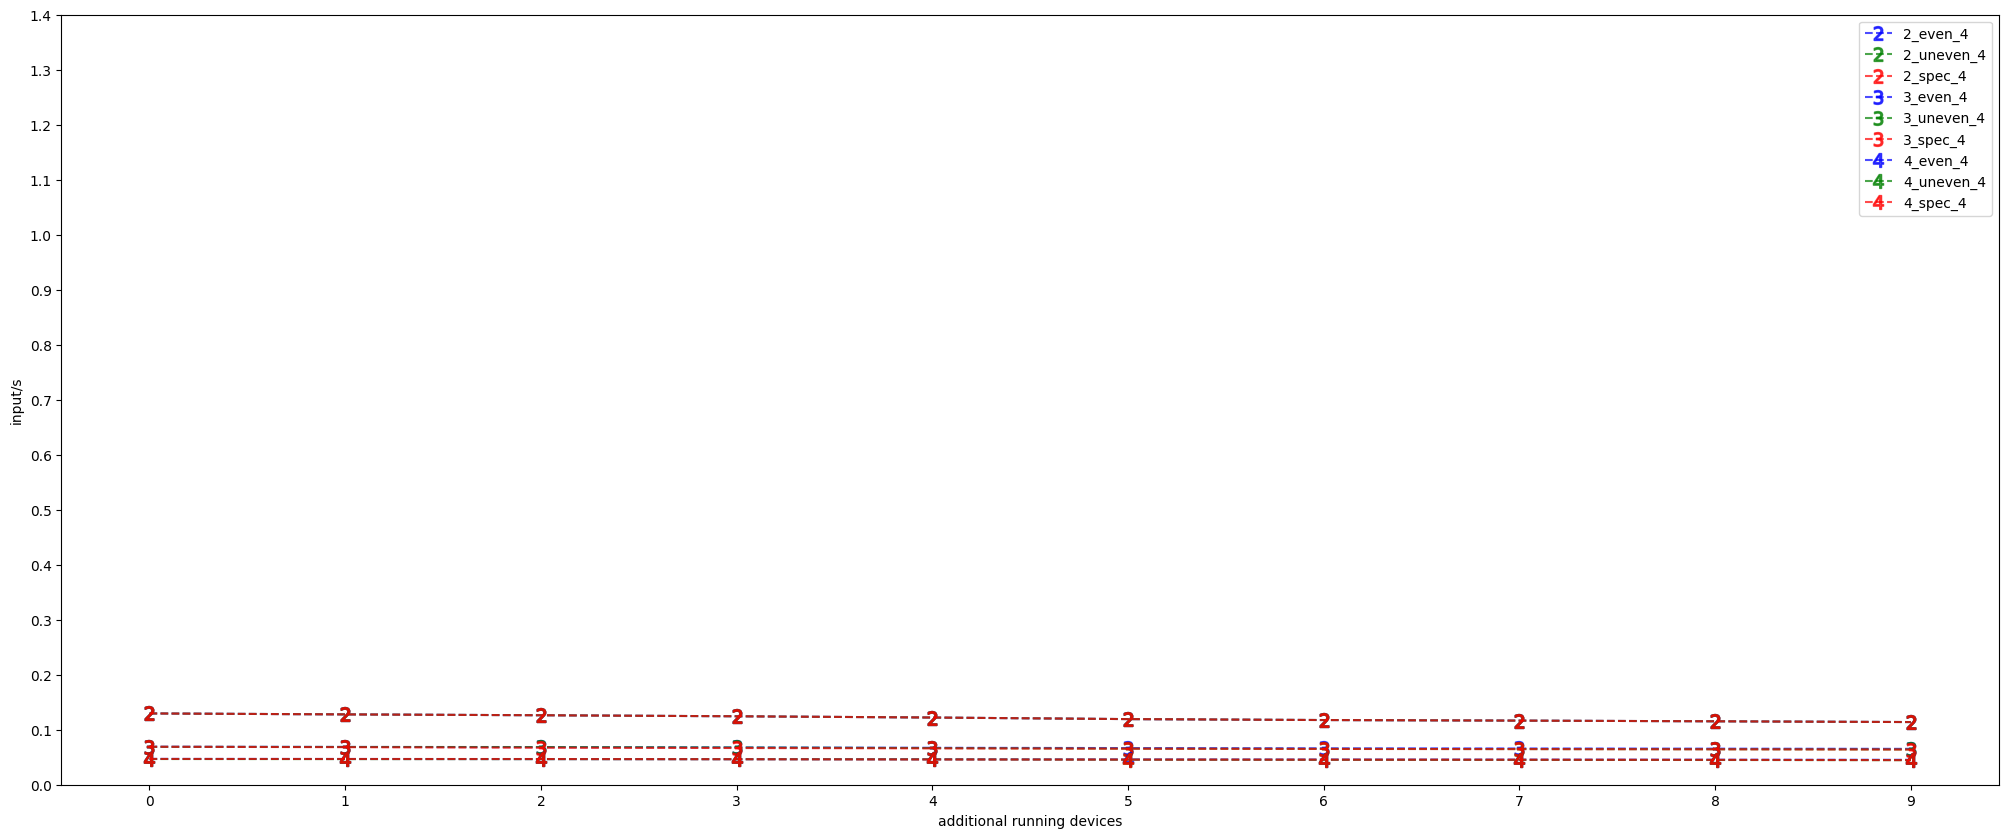

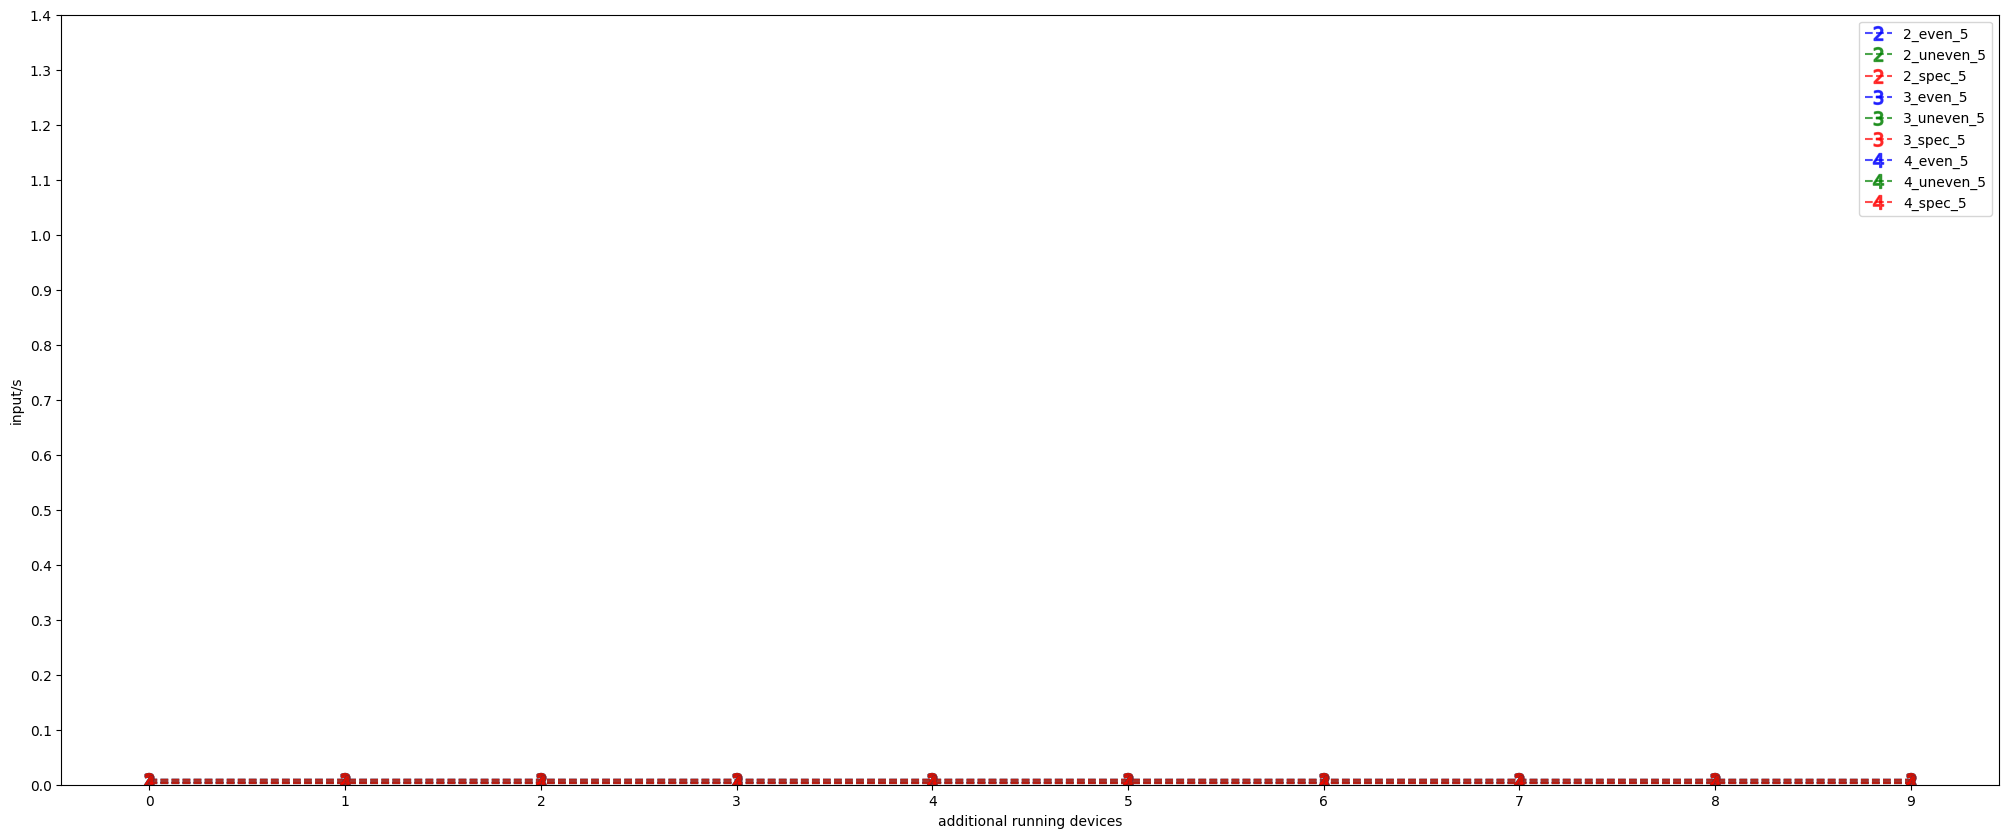

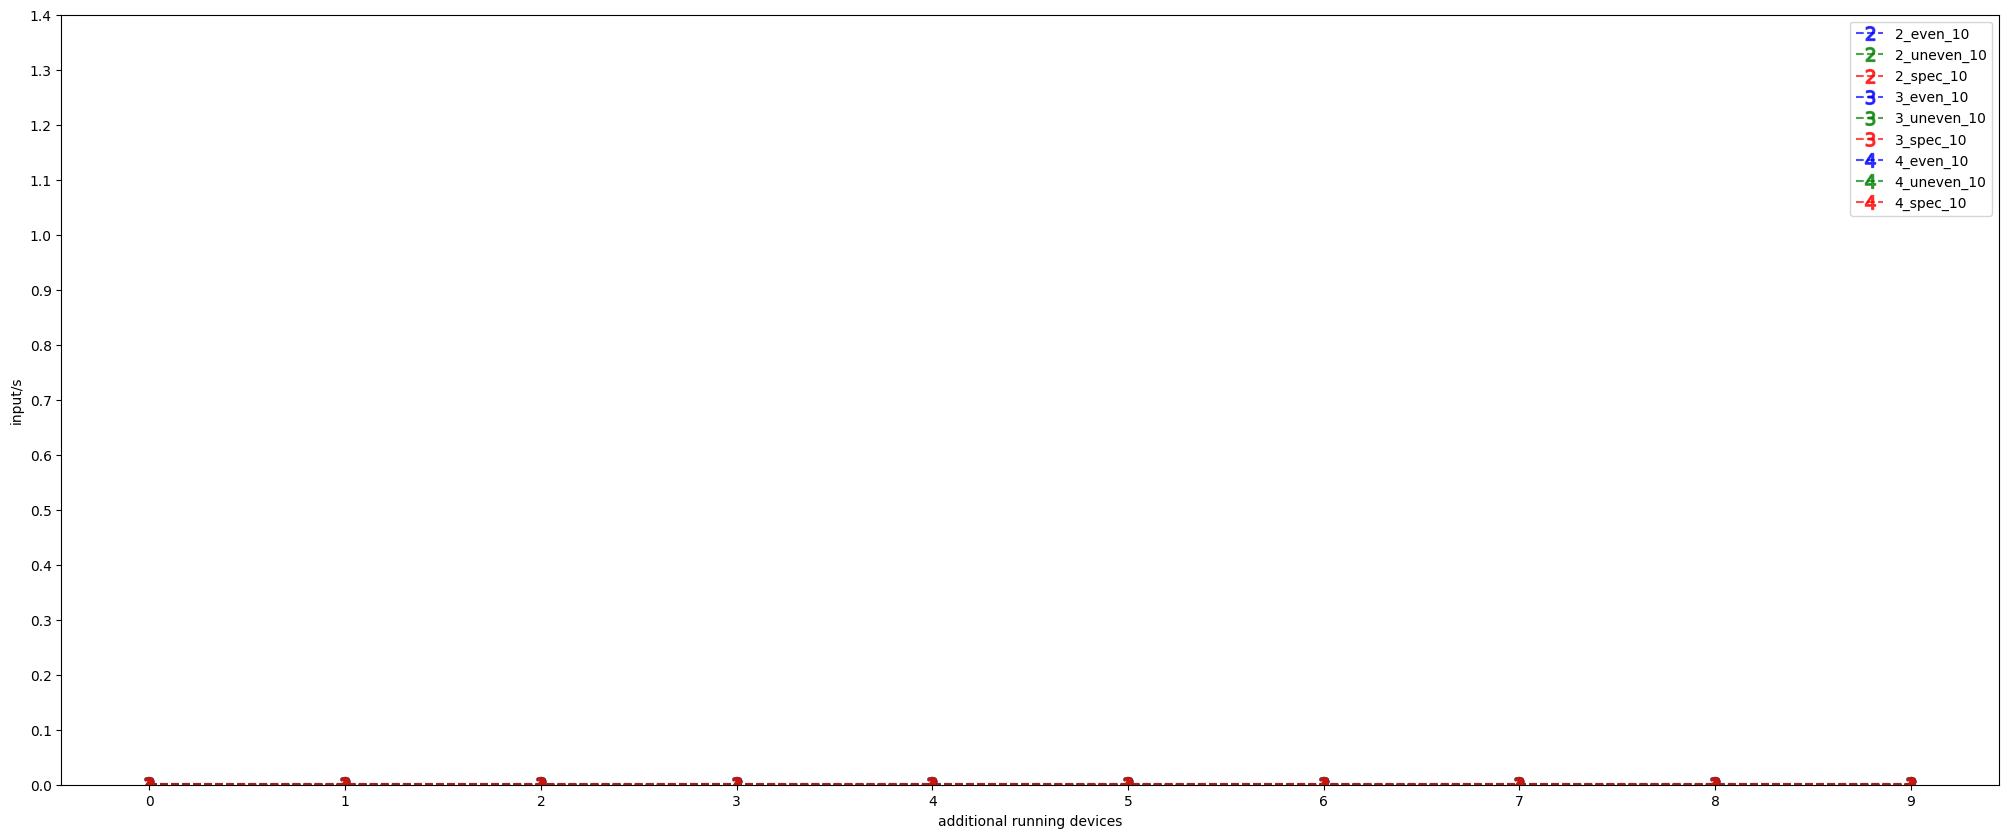

In [91]:
import maybe_broken as mb
import tcn_library

#for resnet
from torchvision.models import resnet18
# print("Testing with ResNet18:")
fixed_iters=1
model = resnet18(weights=None)
model.eval()
res_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))

model = tcn_library.SensorTCN(
            num_channels=8,
            hidden_channels=256,
            levels=8,
            kernel_size=5,
            output_channels=8,
        ).eval()

tcn_splitter = mb.ModelSplitter(model, input_shape=(1,2048,8))

from torchvision.models import vision_transformer
model = vision_transformer.vit_b_16(weights=None)
model.eval()
vit_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))
fixed_bw = 1/270 #1/mbps
lines={1:[],2:[],3:[], 4:[], 5:[],10:[]}
ax_map = {k:[] for k in lines}
for bn in lines:
    fig, axs = plt.subplots(figsize=(25,10))
    ax_map[bn] = [fig, axs]

max_bg = 10
slopes={}
stragglers = {}
# m={2:"x", 3:"^", 4:"", 5:"."}
for world in [2,3,4]:
    if world not in slopes:
        slopes[world] = {k:{"even":[], "uneven":[], "spec":[]} for k in lines}
        stragglers[world] = {k:{"even":[], "uneven":[], "spec":[]} for k in lines}
    
    visited=[]
    even_lines={k:[] for k in lines}
    uneven_lines={k:[] for k in lines}
    spec_lines={k:[] for k in lines}
    
    # for trial in range(10):
    #     mixture = constrained_sum_sample_pos(world, 100)
    #     if mixture not in visited:
    #         visited.append(mixture)
    #     results = res_splitter.split(mixture)
    #     fp = [r['actual_flops']*fixed_iters*10**-9 for r in results['splits']]
    #     nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    #     tnw = [ (10**-2)*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
        
    #     for bn in lines.keys():
    #         img_procs = bn*fixed_iters*4
    #         for b in range(10):
    #             throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
    #             lines[bn].append(img_procs/throttled_latency)
        
    #spec lines
    #even split
    mixture = [100/world]*world
    # results = res_splitter.split(mixture)
    # results = tcn_splitter.split(mixture)
    # vit_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))
    # results = res_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = tcn_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    results = vit_splitter.split(mixture, lookahead=10, alpha=1, beta=1e-6)
    # results = res_splitter.split(mixture)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    # print([f/sum(fp) for f in fp])
    # print([f*10**-3/peak_rate for f in fp], [f/sum(fp) for f in fp], fp)
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    # print(nw[:-1])

    tnw = [ fixed_bw*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    print( f"{world} even:", sum(tnw[:-1]), [f/sum(fp) for f in fp])
    stragglers[world][bn]["even"].append(sum(fp)/sum(tnw[:-1]))


    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        tnw = [bn*fixed_iters*4*t for t in tnw]
        for b in range(max_bg):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            # print(throttled_latency, sum(tnw[:-1]))
            # stragglers[world][bn]["even"].append(1-min_util)

            even_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
            # even_lines[bn].append(img_procs/(throttled_latency))
            # even_lines[bn].append(throttled_latency+sum(tnw[:-1]))
            # even_lines[bn].append(peak_latency+sum(tnw[:-1]))

    #uneven split
    # mixture = [10/(world-1)]*(world-1)+[90] #-> worst version
    mixture = sorted([50*i/(sum(range(1,world))) for i in range(1,world)] + [50])
    # results = res_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = tcn_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    results = vit_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    # print([f*10**-3/peak_rate for f in fp], [f/sum(fp) for f in fp], fp)
    # print([f/sum(fp) for f in fp])
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    # print(nw[:-1])

    tnw = [ fixed_bw*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    print( f"{world} uneven:", sum(tnw[:-1]), [f/sum(fp) for f in fp])
    stragglers[world][bn]["uneven"].append(sum(fp)/sum(tnw[:-1]))

    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        tnw = [bn*fixed_iters*4*t for t in tnw]
        for b in range(max_bg):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            # print(throttled_latency, sum(tnw[:-1]))
            # stragglers[world][bn]["uneven"].append(1-min_util)
            # stragglers[world][bn]["uneven"].append()
            uneven_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
            # uneven_lines[bn].append(img_procs/(throttled_latency))
            # uneven_lines[bn].append(throttled_latency+sum(tnw[:-1]))
            # uneven_lines[bn].append(peak_latency+sum(tnw[:-1]))
    
    #ideal uneven split?
    mixture = sorted([100*(world-1)*i/(world*sum(range(1,world))) for i in range(1,world)] + [100/world])
    # results = res_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = tcn_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    results = vit_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    # print([f/sum(fp) for f in fp])

    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    # print(nw[:-1])
    tnw = [ fixed_bw*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    print( f"{world} spec:", sum(tnw[:-1]), [f/sum(fp) for f in fp])
    stragglers[world][bn]["spec"].append(sum(fp)/sum(tnw[:-1]))

    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        tnw = [bn*fixed_iters*4*t for t in tnw]

        for b in range(max_bg):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            # print(throttled_latency, sum(tnw[:-1]))
            # stragglers[world][bn]["spec"].append(1-min_util)
            spec_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
            
            # print(min_util)
            # spec_lines[bn].append(img_procs/(throttled_latency))
            # spec_lines[bn].append(throttled_latency+sum(tnw[:-1]))
            # spec_lines[bn].append(peak_latency+sum(tnw[:-1]))
    # for bn in lines:
    #     axs.scatter(, alpha=0.2, color=bn_color_map[bn])
    for bn in lines:
        # fig, axs = plt.subplots(figsize=(25,10))
        axs = ax_map[bn][1]
        p = np.polynomial.Polynomial

        slopes[world][bn]["even"].append(p.fit(np.arange(0,max_bg,1), even_lines[bn], 1).convert().coef[1])
        axs.plot(np.arange(0,max_bg,1), even_lines[bn], alpha=0.7, marker=f"${len(fp)}$", markersize=10, linestyle="--", label=f"{world}_even_{bn}", color="blue")
        
        slopes[world][bn]["uneven"].append(p.fit(np.arange(0,max_bg,1), uneven_lines[bn], 1).convert().coef[1])
        axs.plot(np.arange(0,max_bg,1), uneven_lines[bn],alpha=0.7, marker=f"${len(fp)}$",markersize=10, linestyle="--", label=f"{world}_uneven_{bn}", color="green")
        
        slopes[world][bn]["spec"].append(p.fit(np.arange(0,max_bg,1), spec_lines[bn], 1).convert().coef[1])
        axs.plot(np.arange(0,max_bg,1), spec_lines[bn], alpha=0.7, marker=f"${len(fp)}$", markersize=10, linestyle="--", label=f"{world}_spec_{bn}", color="red")
        axs.legend()
        axs.set_xlabel("additional running devices")
        axs.set_ylabel("input/s")
        axs.set_xticks(np.arange(0,max_bg,1))
        # axs.set_yticks(np.arange(0,7,1)) #resnet
        axs.set_yticks(np.arange(0,1.5,0.1)) #vit
# fig, axs = plt.subplots(figsize=(25,10))

# for bn in lines:
#     if bn==5 or bn==10:
#         continue
#     x={"even":[], "uneven":[], "spec":[]}
#     y={"even":[], "uneven":[], "spec":[]}
#     text={"even":[], "uneven":[], "spec":[]}
#     for world in slopes:
#         x["even"].append(abs(slopes[world][bn]["even"][0]))
#         x["uneven"].append(abs(slopes[world][bn]["uneven"][0]))
#         x["spec"].append(abs(slopes[world][bn]["spec"][0]))
#         #because it's 1-min_util its max
#         # y["even"].append(np.max(stragglers[world][bn]["even"]))
#         # y["uneven"].append(np.max(stragglers[world][bn]["uneven"]))
#         # y["spec"].append(np.max(stragglers[world][bn]["spec"]))
#         y["even"].append(stragglers[world][bn]["even"])
#         y["uneven"].append(stragglers[world][bn]["uneven"])
#         y["spec"].append(stragglers[world][bn]["spec"])
#         text["even"].append(f"{world}_{bn}_even")
#         text["uneven"].append(f"{world}_{bn}_uneven")
#         text["spec"].append(f"{world}_{bn}_spec")
#     # print(x,y)
#     axs.scatter(y["even"],x["even"], label=f"{bn}_even")
#     axs.scatter(y["uneven"],x["uneven"], label=f"{bn}_uneven")
#     axs.scatter(y["spec"],x["spec"], label=f"{bn}_spec")
#     for i in range(len(text["even"])):
#         axs.text(y["even"][i], x["even"][i], text["even"][i])
#         axs.text(y["uneven"][i], x["uneven"][i], text["uneven"][i])
#         axs.text(y["spec"][i], x["spec"][i], text["spec"][i])

# axs.legend()

        # break
    # axs.legend()
        # break
    # break
        # axs.plot(np.arange(0,11,1), even_lines[bn])
# results = splitter.split([30, 33, 11, 18, 8])
# fp = 
# for r in results["splits"]:
#     last_layer = r["layers"][-1]

#     print(r['actual_flops'], np.empty(tuple(last_layer["output_shape"]), dtype=np.float32).nbytes*8/10**6)


In [ ]:
import maybe_broken as mb
import tcn_library

#for resnet
from torchvision.models import resnet18
# print("Testing with ResNet18:")
fixed_iters=1
model = resnet18(weights=None)
model.eval()
res_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))

model = tcn_library.SensorTCN(
            num_channels=8,
            hidden_channels=256,
            levels=8,
            kernel_size=5,
            output_channels=8,
        ).eval()

tcn_splitter = mb.ModelSplitter(model, input_shape=(1,2048,8))

from torchvision.models import vision_transformer
model = vision_transformer.vit_b_16(weights=None)
model.eval()
vit_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))
fixed_bw = 1/270 #1/mbps
lines={1:[],2:[],5:[],10:[]}
ax_map = {k:[] for k in lines}
for bn in lines:
    fig, axs = plt.subplots(figsize=(25,10))
    ax_map[bn] = [fig, axs]

max_bg = 10
# m={2:"x", 3:"^", 4:"", 5:"."}
for world in [2,3,4,5]:
    visited=[]
    even_lines={k:[] for k in lines}
    uneven_lines={k:[] for k in lines}
    spec_lines={k:[] for k in lines}
    
    # for trial in range(10):
    #     mixture = constrained_sum_sample_pos(world, 100)
    #     if mixture not in visited:
    #         visited.append(mixture)
    #     results = res_splitter.split(mixture)
    #     fp = [r['actual_flops']*fixed_iters*10**-9 for r in results['splits']]
    #     nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    #     tnw = [ (10**-2)*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
        
    #     for bn in lines.keys():
    #         img_procs = bn*fixed_iters*4
    #         for b in range(10):
    #             throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
    #             lines[bn].append(img_procs/throttled_latency)
        
    #spec lines
    #even split
    mixture = [100/world]*world
    # results = res_splitter.split(mixture)
    # results = tcn_splitter.split(mixture)
    # vit_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))
    results = res_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = tcn_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = vit_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = res_splitter.split(mixture)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    # print([f/sum(fp) for f in fp])
    # print([f*10**-3/peak_rate for f in fp], [f/sum(fp) for f in fp], fp)
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    # print(nw[:-1])

    tnw = [ fixed_bw*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    print( f"{world} even:", sum(tnw[:-1]), [f/sum(fp) for f in fp])

    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        tnw = [bn*fixed_iters*4*t for t in tnw]
        for b in range(max_bg):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            # print(throttled_latency, sum(tnw[:-1]))
            even_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
            # even_lines[bn].append(img_procs/(throttled_latency))
            # even_lines[bn].append(throttled_latency+sum(tnw[:-1]))
            # even_lines[bn].append(peak_latency+sum(tnw[:-1]))

    #uneven split
    # mixture = [10/(world-1)]*(world-1)+[90] #-> worst version
    mixture = [50*i/(sum(range(1,world))) for i in range(1,world)] + [50]
    results = res_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = tcn_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = vit_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    # print([f*10**-3/peak_rate for f in fp], [f/sum(fp) for f in fp], fp)
    # print([f/sum(fp) for f in fp])
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    # print(nw[:-1])

    tnw = [ fixed_bw*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    print( f"{world} uneven:", sum(tnw[:-1]), [f/sum(fp) for f in fp])

    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        tnw = [bn*fixed_iters*4*t for t in tnw]
        for b in range(max_bg):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            # print(throttled_latency, sum(tnw[:-1]))

            uneven_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
            # uneven_lines[bn].append(img_procs/(throttled_latency))
            # uneven_lines[bn].append(throttled_latency+sum(tnw[:-1]))
            # uneven_lines[bn].append(peak_latency+sum(tnw[:-1]))
    
    #ideal uneven split?
    mixture = [100*(world-1)*i/(world*sum(range(1,world))) for i in range(1,world)] + [100/world]
    results = res_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = tcn_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    # results = vit_splitter.split(mixture, lookahead=10, alpha=50, beta=1e-5)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    # print([f/sum(fp) for f in fp])

    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    # print(nw[:-1])
    tnw = [ fixed_bw*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    print( f"{world} spec:", sum(tnw[:-1]), [f/sum(fp) for f in fp])

    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        tnw = [bn*fixed_iters*4*t for t in tnw]

        for b in range(max_bg):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            # print(throttled_latency, sum(tnw[:-1]))
            spec_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
            
            # print(min_util)
            # spec_lines[bn].append(img_procs/(throttled_latency))
            # spec_lines[bn].append(throttled_latency+sum(tnw[:-1]))
            # spec_lines[bn].append(peak_latency+sum(tnw[:-1]))
    # for bn in lines:
    #     axs.scatter(, alpha=0.2, color=bn_color_map[bn])
    for bn in lines:
        # fig, axs = plt.subplots(figsize=(25,10))
        axs = ax_map[bn][1]
        axs.plot(np.arange(0,max_bg,1), even_lines[bn], marker=f"${len(fp)}$", markersize=10, linestyle="--", label=f"{world}_even_{bn}", color="blue")
        axs.plot(np.arange(0,max_bg,1), uneven_lines[bn], marker=f"${len(fp)}$",markersize=10, linestyle="--", label=f"{world}_uneven_{bn}", color="green")
        axs.plot(np.arange(0,max_bg,1), spec_lines[bn], marker=f"${len(fp)}$", markersize=10, linestyle="--", label=f"{world}_spec_{bn}", color="red")
        axs.legend()
        # break
    # axs.legend()
        # break
    # break
        # axs.plot(np.arange(0,11,1), even_lines[bn])
# results = splitter.split([30, 33, 11, 18, 8])
# fp = 
# for r in results["splits"]:
#     last_layer = r["layers"][-1]

#     print(r['actual_flops'], np.empty(tuple(last_layer["output_shape"]), dtype=np.float32).nbytes*8/10**6)
